# Gaussian fit 
KA, Jan2026 - updated

**KA notes:**
- MC outputs adata-labeled.h5ad from this notebook, which is the same as adata-merged-labels.h5ad from the previous notebook, but instead I will just output the table of reporter classifications per barcode. No need to have a separately saved adata object with just the reporter status added

**Pinned Environment:** [`envs/sc-scvi.yaml`](../.../envs/sc-scvi.yaml)  

In [22]:
from pathlib import Path
import os
import sys
import scanpy as sc
import numpy as np
import anndata as ad
import matplotlib.pyplot as plt
import seaborn as sns

### Setup

**NOTE:** 
- MC loaded the following path for the 480 gene dataset, but I don't see this file made anywhere in the processing so far: adata_480_path = base_dir / "data/h5ad/export_02/02b_leiden/adata-leiden-480.h5ad"
- Instead we will use: adata_480_path = base_dir / "data/h5ad/export_01/01b_filter/adata-480.h5ad"

In [23]:
sys.path.append(str(Path.cwd().resolve().parents[1]))

from config.paths import BASE_DIR

base_dir = BASE_DIR

# 475 gene dataset that we have been labeling 
adata_path = base_dir / "data/h5ad/export_03/03a_seurat/adata-merged-labels.h5ad"

# dataset with all 480 genes, including reporter
# adata_480_path = base_dir / "data/h5ad/export_02/02b_leiden/adata-leiden-480.h5ad"
adata_480_path = base_dir / "data/h5ad/export_01/01b_filter/adata-480.h5ad"

output_dir = base_dir / "data/h5ad/export_05/05a_thresholds"
output_dir.mkdir(parents=True, exist_ok=True)

plot_out_dir = os.path.join(base_dir, "plots")
if not os.path.exists (plot_out_dir):
    os.makedirs(plot_out_dir)

table_out_dir = os.path.join(base_dir, "tables")
if not os.path.exists (table_out_dir):
    os.makedirs(table_out_dir)

print(base_dir)
print(adata_path)
print(adata_480_path)

/home/workspace/DRG/spatial_mouse_drg_outputs/yano
/home/workspace/DRG/spatial_mouse_drg_outputs/yano/data/h5ad/export_03/03a_seurat/adata-merged-labels.h5ad
/home/workspace/DRG/spatial_mouse_drg_outputs/yano/data/h5ad/export_01/01b_filter/adata-480.h5ad


### Read and process adata


In [24]:
# global dataset, including reporter genes
adata_480 = sc.read_h5ad(adata_480_path)

# neurons dataset, reporter genes removed 
adata = sc.read_h5ad(adata_path)

In [25]:
for adata_select in [adata, adata_480]:
    print(adata_select.shape)
    print(min(adata_select.obs['total_counts']))

(72778, 475)
51.0
(72778, 480)
51.0


In [26]:
adata

AnnData object with n_obs × n_vars = 72778 × 475
    obs: 'cell_id', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'sample_id', 'output_id', 'region_id', 'slide_id', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_10_genes', 'pct_counts_in_top_20_genes', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_150_genes', 'batch', '_scvi_batch', '_scvi_labels', 'predicted.id', 'prediction.score.CGRP.Theta', 'prediction.score.CGRP.Gamma', 'prediction.score.CGRP.Alpha', 'prediction.score.Nonpeptidergic.nociceptors', 'prediction.score.C.LTMR', 'prediction.score.Sst', 'prediction.score.CGRP.Zeta', 'prediction.score.CGRP.Epsilion', 'prediction.score.Proprioceptors', 'prediction.score.Unknown', 'prediction.score.Adelta.LTMR', 'prediction.

## Gaussian threshold setting

In [27]:
def to_dense(x):
    return x.toarray().ravel() if hasattr(x, "toarray") else np.ravel(x)

from scipy.stats import norm

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm

def to_dense(x):
    return x.toarray().ravel() if hasattr(x, "toarray") else np.ravel(x)

def plot_gaussian(adata_ref, 
                  genes = ["EGFP_Seq1", "dTomato_Seq2"],
                  gene_thresholds = (0.99, 0.99),
                  set_thresholds_on_dual_subsetted_data = False,
                  highlight_barcodes=None, 
                  highlight_color='orange',
                  highlight_size = 30,
                  save_path=None, 
                  return_reporter_classes=False,
                 show_histograms=False):
    
    # Work on copies to avoid unintended side effects
    adata_ref = adata_ref.copy()

    # Standardize gene names
    adata_ref.var_names = adata_ref.var_names.where(adata_ref.var_names != "tdTomato_Seq2", "dTomato_Seq2")
    
    # Ensure we are using raw counts for the math
    adata_ref.X = adata_ref.layers["counts"].copy()
    
    gauss_results = {}

    if set_thresholds_on_dual_subsetted_data: 
        # Raw counts for filtering
        egfp_raw_all = to_dense(adata_ref[:, "EGFP_Seq1"].X)
        td_raw_all   = to_dense(adata_ref[:, "dTomato_Seq2"].X)
        
        # Filter to include only cells with >1 raw count in both genes
        bg_filter_both_reporters = (egfp_raw_all > 1) & (td_raw_all > 1)

    for i, g in enumerate(genes):
        print(g)
        threshold_percentile = gene_thresholds[i]
        
        # 1. Get full expression vector for this gene
        x_raw_full = to_dense(adata_ref[:, g].X)
        x_log_full = np.log1p(x_raw_full)
        
        # 2. INDEPENDENT Background Filter
        # We only use cells with >1 count in THIS gene to model the noise
        specific_bg = x_raw_full > 1 

        # log distribution of cells that pass the gene specific background filter
        x_log_bg = x_log_full[specific_bg]
        
        # 3. Calculate Gaussian parameters from this gene's noise
        if set_thresholds_on_dual_subsetted_data:
            print('setting thresholds using cells with >1 count in both reporters')
            # log distribution of cells that pass the dual gene background filter
            x_log_bg_both_reporters = x_log_full[bg_filter_both_reporters]
            mu, sigma = np.mean(x_log_bg_both_reporters), np.std(x_log_bg_both_reporters)
        else:
            mu, sigma = np.mean(x_log_bg), np.std(x_log_bg)
        multiplier = norm.ppf(threshold_percentile)
        thr_log = mu + multiplier * sigma
        
        # 4. Apply threshold to ALL cells
        # Now a cell with 0 dTomato can still be EGFP_hi
        adata_ref.obs[f"{g}_hi"] = x_log_full > thr_log
        
        gauss_results[g] = {
            "full_log": x_log_full, 
            "thr_log": thr_log
        }
        print(f"{g}: {threshold_percentile} percentile threshold set at {thr_log:.3f} (Z={multiplier:.3f})")

        if show_histograms:
                    plt.figure(figsize=(4, 3))
                    # Plot the background distribution used for the model
                    plt.hist(x_log_bg, bins=100, color='gray', alpha=0.7)
                    # Add the threshold line
                    plt.axvline(thr_log, color='red', linestyle='--', label=f'Threshold: {thr_log:.2f}')
                    plt.title(f"Background Distribution: {g}")
                    plt.xlabel("log1p Expression")
                    plt.ylabel("Frequency")
                    plt.ylim(0,100)
                    plt.legend()
                    sns.despine()
                    plt.show() # This ensures the plot renders before the next loop iteration


    # Identify Dual-high (Logical AND of independent results)
    adata_ref.obs["EGFP_dTomato_dual_hi"] = (
        adata_ref.obs["EGFP_Seq1_hi"] & adata_ref.obs["dTomato_Seq2_hi"]
    )

    # --- Highlight Logic ---
    is_highlight = adata_ref.obs_names.isin(highlight_barcodes) if highlight_barcodes is not None else np.zeros(adata_ref.n_obs, dtype=bool)
    
    # Define plotting groups
    dual_mask = adata_ref.obs["EGFP_dTomato_dual_hi"].values
    final_dual = dual_mask & ~is_highlight
    final_highlight = is_highlight
    
    # --- Plotting ---
    x_egfp = gauss_results["EGFP_Seq1"]["full_log"]
    x_td = gauss_results["dTomato_Seq2"]["full_log"]
    
    sns.set_theme(style="ticks")
    plt.figure(figsize=(3, 3), dpi=300)
    ax = plt.gca()

    # 1. All cells (Background)
    ax.scatter(x_egfp, x_td, s=2, color="lightgray", alpha=0.1, label="Background", rasterized=True)

    # 2. Dual Positive cells (Blue)
    if final_dual.any():
        ax.scatter(x_egfp[final_dual], x_td[final_dual], 
                   s=30, facecolors=(0.0, 0.47, 1.0, 0.4), edgecolors="blue", 
                   linewidths=0.8, label="Dual Positive")

    # 3. Highlighted cells (Orange/Custom) - Drawn last with high zorder
    if final_highlight.any():
        print(f"number of barcodes to highlight: {sum(final_highlight)}")
        ax.scatter(x_egfp[final_highlight], x_td[final_highlight], 
                   s=highlight_size, facecolors=highlight_color, 
                   alpha=1.0, label="Highlighted", zorder=10)

    # Threshold lines
    ax.axvline(gauss_results["EGFP_Seq1"]["thr_log"], color="red", ls="--", lw=1, alpha=0.8)
    ax.axhline(gauss_results["dTomato_Seq2"]["thr_log"], color="red", ls="--", lw=1, alpha=0.8)

    ax.set_xlabel("log1p EGFP_Seq1")
    ax.set_ylabel("log1p dTomato_Seq2")
    sns.despine()
    
    if save_path:
        plt.savefig(save_path, bbox_inches='tight')
    plt.show()

    if return_reporter_classes:
        return adata_ref.obs[['sample_id', 'EGFP_Seq1_hi', 'dTomato_Seq2_hi', 'EGFP_dTomato_dual_hi']]

EGFP_Seq1
EGFP_Seq1: 0.9995 percentile threshold set at 3.425 (Z=3.291)
dTomato_Seq2
dTomato_Seq2: 0.999 percentile threshold set at 2.309 (Z=3.090)


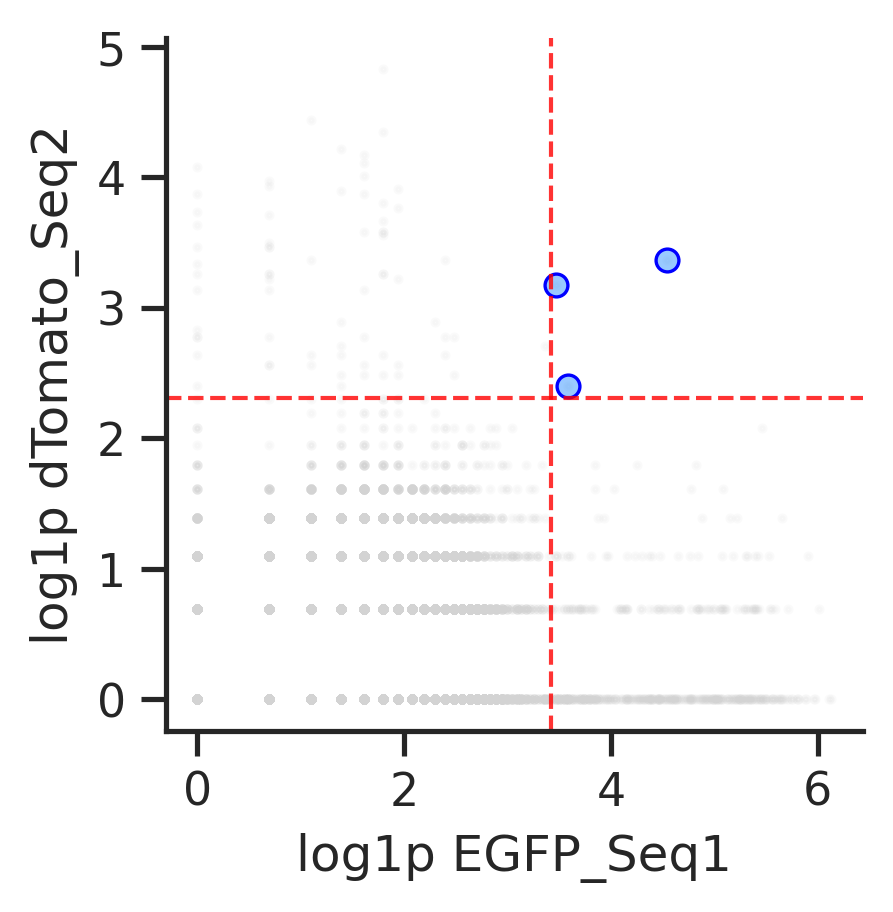

484
72
3


/tmp/ipykernel_961/1385945759.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  reporter_classes_updated_dual['reporter_status'] = 'Negative'


In [28]:
# use thresholds set on both reporters
# first run filtering
reporter_classes_updated_dual = plot_gaussian(adata_480, 
                                            genes = ["EGFP_Seq1", "dTomato_Seq2"],
                                            gene_thresholds = (0.9995, 0.999),
                                              # highlight_barcodes = ab_gfp_barcodes, highlight_color = 'green', highlight_size=10,
                                            set_thresholds_on_dual_subsetted_data = False,
                                            return_reporter_classes = True,
                                            save_path = os.path.join(plot_out_dir, "gaussian_thresholds_on_global_data.pdf")
                                             )

# add reporter status, either single positive or double postivie or negative
reporter_classes_updated_dual['reporter_status'] = 'Negative'
reporter_classes_updated_dual.loc[reporter_classes_updated_dual['EGFP_Seq1_hi']==True, 'reporter_status'] = 'EGFP_Seq1_hi'
reporter_classes_updated_dual.loc[reporter_classes_updated_dual['dTomato_Seq2_hi']==True, 'reporter_status'] = 'dTomato_Seq2_hi'
reporter_classes_updated_dual.loc[reporter_classes_updated_dual['EGFP_dTomato_dual_hi']==True, 'reporter_status'] = 'EGFP_dTomato_dual_hi'


print(sum(reporter_classes_updated_dual['EGFP_Seq1_hi']))
print(sum(reporter_classes_updated_dual['dTomato_Seq2_hi']))
print(sum(reporter_classes_updated_dual['EGFP_dTomato_dual_hi']))

In [29]:
reporter_classes_updated_dual.head()

,sample_id,EGFP_Seq1_hi,dTomato_Seq2_hi,EGFP_dTomato_dual_hi,reporter_status
aaaacmnk-1-0,TMA00316,False,False,False,Negative
aaababeb-1-0,TMA00316,False,False,False,Negative
aaaegioj-1-0,TMA00316,False,False,False,Negative
aadidbcn-1-0,TMA00316,False,False,False,Negative
aaeepbcc-1-0,TMA00316,False,False,False,Negative


## update adata object

In [30]:
cols_update = ['EGFP_Seq1_hi', 'dTomato_Seq2_hi', 'EGFP_dTomato_dual_hi', 'reporter_status']
for col in cols_update:
    if col in adata.obs.columns:
        print(f"deleting {col}")
        del adata.obs[col]

# add individual reporter columns
adata.obs = adata.obs.join(reporter_classes_updated_dual[['EGFP_Seq1_hi', 'dTomato_Seq2_hi', 'EGFP_dTomato_dual_hi', 'reporter_status']])



## Check reporter numbers

In [31]:
# Show single+ all together
counts_series = adata.obs.value_counts(['EGFP_Seq1_hi', 'dTomato_Seq2_hi', 'EGFP_dTomato_dual_hi'])
counts_df = counts_series.reset_index(name='cell_count')
counts_df

,EGFP_Seq1_hi,dTomato_Seq2_hi,EGFP_dTomato_dual_hi,cell_count
0,False,False,False,72225
1,True,False,False,481
2,False,True,False,69
3,True,True,True,3


In [32]:
reporter_classes_updated_dual

,sample_id,EGFP_Seq1_hi,dTomato_Seq2_hi,EGFP_dTomato_dual_hi,reporter_status
aaaacmnk-1-0,TMA00316,False,False,False,Negative
aaababeb-1-0,TMA00316,False,False,False,Negative
aaaegioj-1-0,TMA00316,False,False,False,Negative
aadidbcn-1-0,TMA00316,False,False,False,Negative
aaeepbcc-1-0,TMA00316,False,False,False,Negative
...,...,...,...,...,...
ohpdlnah-1-3,TMA00315,False,False,False,Negative
ohpedfnp-1-3,TMA00315,False,False,False,Negative
oicbjhcp-1-3,TMA00315,False,False,False,Negative
oieanihb-1-3,TMA00315,False,False,False,Negative


In [33]:
counts_series = reporter_classes_updated_dual.value_counts(['reporter_status'])
counts_df = counts_series.reset_index(name='cell_count')
counts_df

,reporter_status,cell_count
0,Negative,72225
1,EGFP_Seq1_hi,481
2,dTomato_Seq2_hi,69
3,EGFP_dTomato_dual_hi,3


## Save table of reporter assignments per cell barcode

In [34]:
reporter_classes_updated_dual.to_csv(os.path.join(output_dir, 'reporter_classes_gaussian_thresholds.csv'))